# RTFM Segment Scoring + Video-Level Gate

Runs all test videos through the trained RTFM model and produces **per-segment anomaly scores** (32 segments per video).  
A lightweight **Video-Level Gate** then decides whether a video is worth further analysis:

```
max(segment_scores) > GATE_THRESHOLD
    → True  : video flagged as anomalous → proceed to downstream sampling
    → False : video is normal → skip entirely (return early)
```

Results are saved to `MyDrive/rtfm_checkpoints/segment_scores.json`.

In [9]:
# ── Cell 1: GPU check ────────────────────────────────────────────────────────
import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'Memory  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : NVIDIA A100-SXM4-40GB
Memory  : 42.4 GB


In [10]:
# ── Cell 2: Setup — mount drive, unzip data, fix paths, load checkpoint ───────
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, sys, importlib, importlib.util

os.makedirs('/content/rtfm', exist_ok=True)

# Unzip feature data if not already present
if not os.path.exists('/content/rtfm/data'):
    !unzip -q /content/drive/MyDrive/rtfm_colab.zip -d /content/rtfm
    print('Unzipped data.')
else:
    print('Data already present.')

# Copy Python source files from Drive
src_dir = '/content/drive/MyDrive/rtfm_src'
for fname in ['model.py', 'dataset.py', 'option.py', 'utils.py', 'config.py']:
    dst = f'/content/rtfm/{fname}'
    src = f'{src_dir}/{fname}'
    if not os.path.exists(dst):
        if os.path.exists(src):
            shutil.copy2(src, dst)
            print(f'Copied {fname}')
        else:
            print(f'WARNING: {fname} not found in {src}')

# Fix paths in test list file
list_path = '/content/rtfm/list/shanghai-i3d-test-10crop.list'
with open(list_path) as f:
    lines = f.readlines()
fixed = [f'/content/rtfm/data/SH_Test_ten_crop_i3d/{l.strip().split("/")[-1]}\n' for l in lines]
with open(list_path, 'w') as f:
    f.writelines(fixed)
print(f'Test list: {len(fixed)} entries  |  e.g. {fixed[0].strip()}')

# Copy checkpoint from Drive
os.makedirs('/content/rtfm/ckpt', exist_ok=True)
ckpt_src = '/content/drive/MyDrive/rtfm_checkpoints/rtfm_best.pkl'
ckpt_dst = '/content/rtfm/ckpt/rtfm_best.pkl'
if not os.path.exists(ckpt_dst):
    shutil.copy2(ckpt_src, ckpt_dst)
    print('Checkpoint copied.')
else:
    print('Checkpoint already present.')

# Load modules
os.chdir('/content/rtfm')
sys.path.insert(0, '/content/rtfm')

def _load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod  = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

option  = _load_module('option',  '/content/rtfm/option.py')
model_m = _load_module('model',   '/content/rtfm/model.py')

import numpy as np
from torch.utils.data import DataLoader

args   = option.parser.parse_args([])
device = torch.device('cuda')

net = model_m.Model(args.feature_size, args.batch_size)
net.load_state_dict(torch.load(ckpt_dst, map_location='cuda'))
net = net.to(device).eval()
print('Model loaded and ready.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data already present.
Test list: 199 entries  |  e.g. /content/rtfm/data/SH_Test_ten_crop_i3d/01_0015_i3d.npy
Checkpoint already present.
Model loaded and ready.


In [14]:
# ── Cell 3: Score all test videos + Video-Level Gate ─────────────────────────
#
# Gate signal: score_abnormal  (paper-correct aggregation)
# ─────────────────────────────────────────────────────────────────────────────
# RTFM Theorem 3.1 proves separability is maximised at k ≈ μ (true anomalous
# snippets per video), NOT at k=1 (max) or k=∞ (mean).
# The model is trained with k = num_segments // 10 = 3, selecting the top-3
# segments by FEATURE MAGNITUDE and averaging their classification scores.
# That aggregated value is returned as score_abnormal (index 0 in the output
# tuple) — exactly the video-level signal the paper optimises.
# We use it directly as our gate score instead of max(segment_scores).
# ─────────────────────────────────────────────────────────────────────────────

# ┌─────────────────────────────────────────────┐
# │  CONFIG — adjust GATE_THRESHOLD as needed   │
# └─────────────────────────────────────────────┘
GATE_THRESHOLD = 0.2   # score_abnormal must exceed this to flag a video
                       # 0.2 ≈ optimal F1 threshold (90.9% recall, 87% precision, F1=88.9%)
                       # 0.5 → higher precision (97%) but misses 25% of anomalous videos
TOP_K_SEGMENTS = 5     # top segment indices to record for flagged videos (for downstream sampling)

# ── Load test file list ───────────────────────────────────────────────────────
with open('/content/rtfm/list/shanghai-i3d-test-10crop.list') as f:
    test_paths = [l.strip() for l in f.readlines() if l.strip()]

print(f'Test videos    : {len(test_paths)}')
print(f'Gate threshold : {GATE_THRESHOLD}')
print(f'Gate signal    : score_abnormal (top-{net.k_abn} magnitude snippets, mean classification score)')
print()

# ── Inference loop ────────────────────────────────────────────────────────────
results   = {}   # video_name → dict
n_flagged = 0
n_skipped = 0

with torch.no_grad():
    for idx, path in enumerate(test_paths):
        video_name = os.path.basename(path).replace('.npy', '')

        # Load I3D features: shape [T, 10, 2048]  (T segments, 10 crops, 2048-d)
        features = np.load(path, allow_pickle=True).astype(np.float32)
        inp = torch.from_numpy(features).unsqueeze(0).to(device)  # [1, T, 10, 2048]
        inp = inp.permute(0, 2, 1, 3)                              # [1, 10, T, 2048]

        # Forward pass
        # score_abnormal: mean classification score of top-k magnitude segments (paper gate signal)
        # logits:         per-segment classification scores [1, T, 1]
        score_abnormal, _, _, _, _, _, logits, _, _, _ = net(inputs=inp)

        # ── Per-segment scores (for downstream sampling) ──────────────────────
        logits     = torch.squeeze(logits, 1)
        logits     = torch.mean(logits, 0)
        seg_scores = logits.squeeze().cpu().numpy()      # 1-D array, length T
        n_segments = int(seg_scores.shape[0]) if seg_scores.ndim > 0 else 1
        if seg_scores.ndim == 0:
            seg_scores = seg_scores.reshape(1)

        # ── Gate score: score_abnormal (paper Theorem 3.1, k=3) ──────────────
        gate_score = float(score_abnormal.squeeze().cpu())

        # ── VIDEO-LEVEL GATE ─────────────────────────────────────────────────
        if gate_score <= GATE_THRESHOLD:
            # Normal — skip entirely, no downstream processing needed
            n_skipped += 1
            results[video_name] = {
                'segment_scores' : seg_scores.tolist(),
                'n_segments'     : n_segments,
                'gate_score'     : gate_score,
                'max_seg_score'  : float(seg_scores.max()),
                'flagged'        : False,
            }
            continue

        # Anomalous — proceed to downstream sampling
        n_flagged += 1
        top_seg_indices = sorted(
            range(n_segments),
            key=lambda i: seg_scores[i],
            reverse=True
        )[:TOP_K_SEGMENTS]

        results[video_name] = {
            'segment_scores' : seg_scores.tolist(),
            'n_segments'     : n_segments,
            'gate_score'     : gate_score,       # paper-correct video-level score
            'max_seg_score'  : float(seg_scores.max()),
            'flagged'        : True,
            'top_segments'   : top_seg_indices,  # ranked indices for downstream sampling
        }

        if (idx + 1) % 20 == 0 or (idx + 1) == len(test_paths):
            print(f'  [{idx+1:3d}/{len(test_paths)}]  '
                  f'flagged={n_flagged}  skipped={n_skipped}  '
                  f'last={video_name}  gate={gate_score:.3f}')

print()
print(f'Done.  Total={len(results)}  Flagged={n_flagged}  Skipped(normal)={n_skipped}')

Test videos    : 199
Gate threshold : 0.2
Gate signal    : score_abnormal (top-3 magnitude snippets, mean classification score)

  [ 20/199]  flagged=17  skipped=3  last=03_0033_i3d  gate=0.725
  [ 40/199]  flagged=36  skipped=4  last=10_0042_i3d  gate=0.426

Done.  Total=199  Flagged=46  Skipped(normal)=153


In [15]:
# ── Cell 4: Summary stats + save results to Drive ────────────────────────────
import json

flagged_scores = [v['gate_score'] for v in results.values() if v['flagged']]
normal_scores  = [v['gate_score'] for v in results.values() if not v['flagged']]

print(f'Gate threshold : {GATE_THRESHOLD}  (signal: score_abnormal, top-k={net.k_abn} magnitude snippets)')
print(f'Flagged videos : {len(flagged_scores):4d}  '
      f'gate_score  mean={np.mean(flagged_scores):.3f}  '
      f'min={np.min(flagged_scores):.3f}  max={np.max(flagged_scores):.3f}')
print(f'Skipped videos : {len(normal_scores):4d}  '
      f'gate_score  mean={np.mean(normal_scores):.3f}  '
      f'min={np.min(normal_scores):.3f}  max={np.max(normal_scores):.3f}')

# Top 10 most anomalous
sorted_flagged = sorted(
    [(name, v['gate_score'], v.get('top_segments', []))
     for name, v in results.items() if v['flagged']],
    key=lambda x: x[1], reverse=True
)
print()
print('Top 10 most anomalous videos:')
for name, score, top_segs in sorted_flagged[:10]:
    print(f'  {score:.4f}  segs={top_segs}  {name}')

# Save full results JSON
output = {
    'gate_threshold' : GATE_THRESHOLD,
    'top_k_segments' : TOP_K_SEGMENTS,
    'summary' : {
        'total'   : len(results),
        'flagged' : len(flagged_scores),
        'skipped' : len(normal_scores),
    },
    'videos' : results,
}

local_path = '/content/rtfm/segment_scores.json'
with open(local_path, 'w') as f:
    json.dump(output, f, indent=2)
print(f'\nSaved locally : {local_path}')

# Copy to Google Drive
drive_out = '/content/drive/MyDrive/rtfm_checkpoints/segment_scores.json'
shutil.copy2(local_path, drive_out)
print(f'Saved to Drive : {drive_out}')

# Optionally also save as numpy for fast loading
np.save('/content/rtfm/segment_scores_all.npy', results)
print('Also saved segment_scores_all.npy')

Gate threshold : 0.2  (signal: score_abnormal, top-k=3 magnitude snippets)
Flagged videos :   46  gate_score  mean=0.681  min=0.214  max=1.000
Skipped videos :  153  gate_score  mean=0.019  min=0.000  max=0.195

Top 10 most anomalous videos:
  0.9999  segs=[11, 10, 12, 9, 8]  01_0025_i3d
  0.9995  segs=[8, 9, 7, 10, 6]  12_0174_i3d
  0.9980  segs=[11, 12, 10, 9, 13]  01_0053_i3d
  0.9978  segs=[12, 11, 13, 10, 14]  03_0032_i3d
  0.9978  segs=[7, 8, 9, 10, 6]  12_0142_i3d
  0.9977  segs=[14, 12, 15, 13, 11]  01_0135_i3d
  0.9922  segs=[7, 6, 8, 9, 10]  12_0173_i3d
  0.9888  segs=[8, 9, 11, 28, 7]  04_0004_i3d
  0.9870  segs=[9, 11, 12, 8, 10]  12_0151_i3d
  0.9831  segs=[16, 17, 18, 19, 14]  05_0023_i3d

Saved locally : /content/rtfm/segment_scores.json
Saved to Drive : /content/drive/MyDrive/rtfm_checkpoints/segment_scores.json
Also saved segment_scores_all.npy


GT  →  Anomalous: 44  |  Normal: 155  |  Total: 199

=== Video-Level Gate  (threshold = 0.2) ===
  TP (anom, correctly flagged) : 40
  TN (normal, correctly skipped): 149
  FP (normal, falsely flagged) : 6
  FN (anom, missed)            : 4

  Accuracy  : 0.9497
  Precision : 0.8696  (of flagged, how many truly anomalous)
  Recall    : 0.9091  (of anomalous, how many caught)
  F1        : 0.8889
  ROC-AUC   : 0.9858  (video-level, threshold-free)

              precision    recall  f1-score   support

      Normal       0.97      0.96      0.97       155
   Anomalous       0.87      0.91      0.89        44

    accuracy                           0.95       199
   macro avg       0.92      0.94      0.93       199
weighted avg       0.95      0.95      0.95       199

=== Best threshold by F1 ===
  Threshold : 0.196
  F1        : 0.8889
  Accuracy  : 0.9497
  Precision : 0.8696
  Recall    : 0.9091


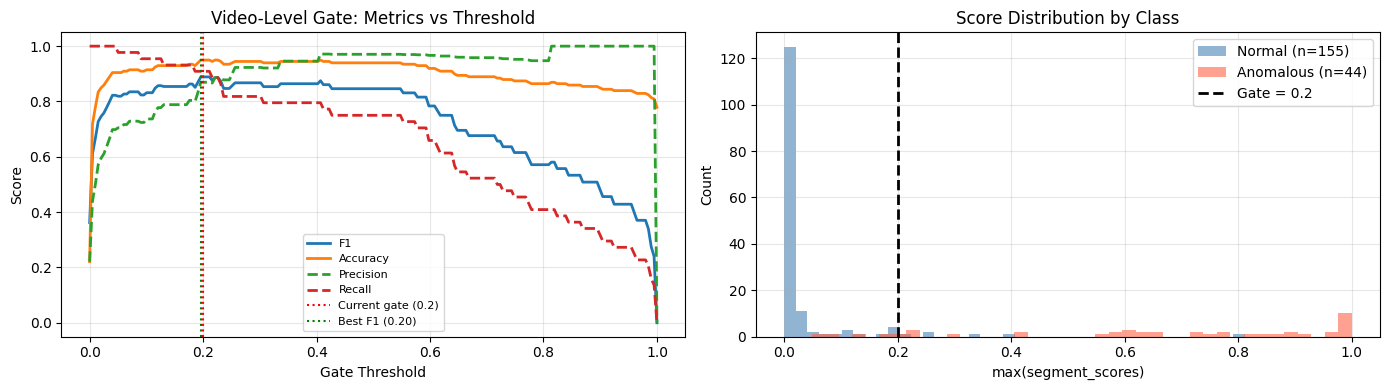

Plot saved to Drive.


In [16]:
# ── Cell 5: Video-Level Accuracy (4-digit clip ID = anomalous ground truth) ───
#
# ShanghaiTech naming convention (confirmed by make_gt_sh.py):
#   XX_YYYY_i3d  (4-digit second part) → anomalous  (first 44 in test list)
#   XX_YYY_i3d   (3-digit second part) → normal     (remaining 155)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
)

# ── Build GT and score vectors in list order ─────────────────────────────────
with open('/content/rtfm/list/shanghai-i3d-test-10crop.list') as f:
    ordered_paths = [l.strip() for l in f if l.strip()]

video_names  = [os.path.basename(p).replace('.npy', '') for p in ordered_paths]
gt_labels   = []
gate_scores = []

for name in video_names:
    clip_id = name.replace('_i3d', '').split('_')[1]   # e.g. '0015' or '001'
    gt_labels.append(1 if len(clip_id) == 4 else 0)
    gate_scores.append(results[name]['gate_score'])

gt_labels   = np.array(gt_labels)
gate_scores = np.array(gate_scores)

n_anom   = gt_labels.sum()
n_normal = (gt_labels == 0).sum()
print(f'GT  →  Anomalous: {n_anom}  |  Normal: {n_normal}  |  Total: {len(gt_labels)}')
print()

# ── Metrics at chosen gate threshold ─────────────────────────────────────────
preds = (gate_scores > GATE_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(gt_labels, preds).ravel()

print(f'=== Video-Level Gate  (threshold = {GATE_THRESHOLD}) ===')
print(f'  TP (anom, correctly flagged) : {tp}')
print(f'  TN (normal, correctly skipped): {tn}')
print(f'  FP (normal, falsely flagged) : {fp}')
print(f'  FN (anom, missed)            : {fn}')
print()
print(f'  Accuracy  : {accuracy_score(gt_labels, preds):.4f}')
print(f'  Precision : {precision_score(gt_labels, preds):.4f}  (of flagged, how many truly anomalous)')
print(f'  Recall    : {recall_score(gt_labels, preds):.4f}  (of anomalous, how many caught)')
print(f'  F1        : {f1_score(gt_labels, preds):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(gt_labels, gate_scores):.4f}  (video-level, threshold-free)')
print()
print(classification_report(gt_labels, preds, target_names=['Normal', 'Anomalous']))

# ── Threshold sweep: find the best gate threshold ────────────────────────────
thresholds = np.linspace(0.0, 1.0, 200)
f1s, accs, precs, recs = [], [], [], []

for t in thresholds:
    p = (gate_scores > t).astype(int)
    f1s.append(f1_score(gt_labels, p, zero_division=0))
    accs.append(accuracy_score(gt_labels, p))
    precs.append(precision_score(gt_labels, p, zero_division=0))
    recs.append(recall_score(gt_labels, p, zero_division=0))


best_idx = int(np.argmax(f1s))
print(f'=== Best threshold by F1 ===')
print(f'  Threshold : {thresholds[best_idx]:.3f}')
print(f'  F1        : {f1s[best_idx]:.4f}')
print(f'  Accuracy  : {accs[best_idx]:.4f}')
print(f'  Precision : {precs[best_idx]:.4f}')
print(f'  Recall    : {recs[best_idx]:.4f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(thresholds, f1s,   label='F1',        lw=2)
ax.plot(thresholds, accs,  label='Accuracy',  lw=2)
ax.plot(thresholds, precs, label='Precision', lw=2, ls='--')
ax.plot(thresholds, recs,  label='Recall',    lw=2, ls='--')
ax.axvline(GATE_THRESHOLD,      color='red',   ls=':', lw=1.5, label=f'Current gate ({GATE_THRESHOLD})')
ax.axvline(thresholds[best_idx], color='green', ls=':', lw=1.5, label=f'Best F1 ({thresholds[best_idx]:.2f})')
ax.set_xlabel('Gate Threshold')
ax.set_ylabel('Score')
ax.set_title('Video-Level Gate: Metrics vs Threshold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
scores_anom   = gate_scores[gt_labels == 1]
scores_normal = gate_scores[gt_labels == 0]
ax.hist(scores_normal, bins=40, alpha=0.6, label=f'Normal (n={n_normal})', color='steelblue')
ax.hist(scores_anom,   bins=40, alpha=0.6, label=f'Anomalous (n={n_anom})', color='tomato')
ax.axvline(GATE_THRESHOLD, color='black', ls='--', lw=2, label=f'Gate = {GATE_THRESHOLD}')
ax.set_xlabel('max(segment_scores)')
ax.set_ylabel('Count')
ax.set_title('Score Distribution by Class')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/rtfm/gate_accuracy.png', dpi=150, bbox_inches='tight')
shutil.copy2('/content/rtfm/gate_accuracy.png',
             '/content/drive/MyDrive/rtfm_checkpoints/gate_accuracy.png')
plt.show()
print('Plot saved to Drive.')

Train videos   : 238
Gate threshold : 0.2  (same as test — no re-tuning)

  [ 40/238]  flagged=40  skipped=0  last=06_0155_i3d  gate=0.987
  [ 80/238]  flagged=63  skipped=17  last=01_024_i3d  gate=0.001
  [120/238]  flagged=64  skipped=56  last=04_004_i3d  gate=0.001
  [160/238]  flagged=64  skipped=96  last=05_059_i3d  gate=0.001
  [200/238]  flagged=64  skipped=136  last=08_035_i3d  gate=0.012
  [238/238]  flagged=66  skipped=172  last=13_007_i3d  gate=0.007

Done.  Total=238  Flagged=66  Skipped=172

=== Training Set  (threshold = 0.2, same as test) ===
  TP : 63  |  TN : 172  |  FP : 3  |  FN : 0
  Accuracy  : 0.9874
  Precision : 0.9545
  Recall    : 1.0000
  F1        : 0.9767
  ROC-AUC   : 1.0000

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       175
   Anomalous       0.95      1.00      0.98        63

    accuracy                           0.99       238
   macro avg       0.98      0.99      0.98       238
weighted avg 

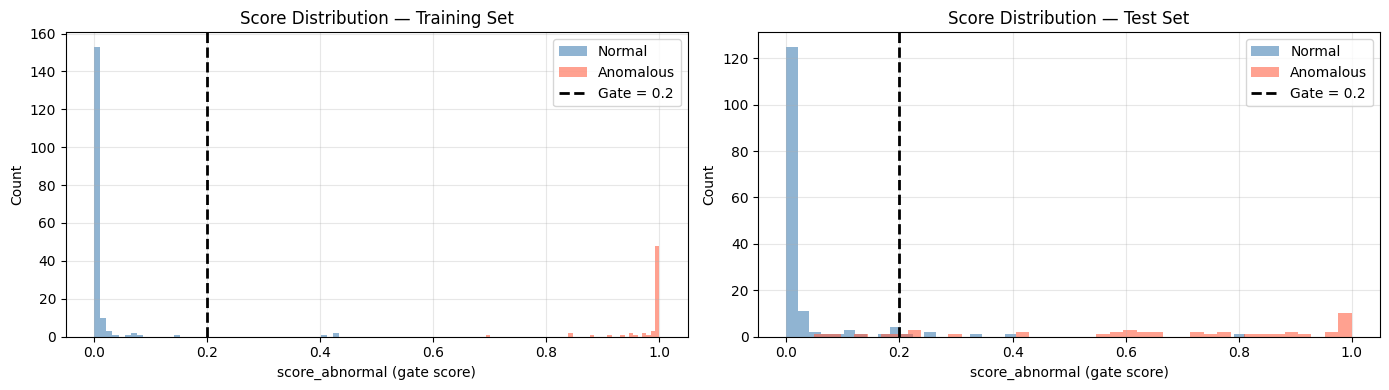

Train results saved to Drive.


In [17]:
# ── Cell 6: Run gate on TRAINING set (same threshold, no tuning) ─────────────
# Purpose: check whether GATE_THRESHOLD=0.2 generalises beyond the test set.
# Training set: 238 videos  |  63 anomalous (4-digit)  |  175 normal (3-digit)
# NOTE: the model was TRAINED on these videos — expect near-perfect scores here.
#       This is mainly a sanity check, not a fair generalisation measure.

train_list_path = '/content/rtfm/list/shanghai-i3d-train-10crop.list'

# Fix paths to Colab if needed
with open(train_list_path) as f:
    train_lines = f.readlines()
train_fixed = [f'/content/rtfm/data/SH_Train_ten_crop_i3d/{l.strip().split("/")[-1]}\n'
               for l in train_lines if l.strip()]
with open(train_list_path, 'w') as f:
    f.writelines(train_fixed)

train_paths = [l.strip() for l in train_fixed]
print(f'Train videos   : {len(train_paths)}')
print(f'Gate threshold : {GATE_THRESHOLD}  (same as test — no re-tuning)')
print()

train_results = {}
n_flagged_tr  = 0
n_skipped_tr  = 0

with torch.no_grad():
    for idx, path in enumerate(train_paths):
        video_name = os.path.basename(path).replace('.npy', '')

        features = np.load(path, allow_pickle=True).astype(np.float32)
        inp = torch.from_numpy(features).unsqueeze(0).to(device)
        inp = inp.permute(0, 2, 1, 3)

        score_abnormal, _, _, _, _, _, logits, _, _, _ = net(inputs=inp)

        logits     = torch.squeeze(logits, 1)
        logits     = torch.mean(logits, 0)
        seg_scores = logits.squeeze().cpu().numpy()
        n_segments = int(seg_scores.shape[0]) if seg_scores.ndim > 0 else 1
        if seg_scores.ndim == 0:
            seg_scores = seg_scores.reshape(1)

        gate_score = float(score_abnormal.squeeze().cpu())

        top_seg_indices = sorted(range(n_segments),
                                 key=lambda i: seg_scores[i],
                                 reverse=True)[:TOP_K_SEGMENTS]

        flagged = gate_score > GATE_THRESHOLD
        if flagged:
            n_flagged_tr += 1
        else:
            n_skipped_tr += 1

        train_results[video_name] = {
            'segment_scores' : seg_scores.tolist(),
            'n_segments'     : n_segments,
            'gate_score'     : gate_score,
            'max_seg_score'  : float(seg_scores.max()),
            'flagged'        : flagged,
            'top_segments'   : top_seg_indices if flagged else [],
        }

        if (idx + 1) % 40 == 0 or (idx + 1) == len(train_paths):
            print(f'  [{idx+1:3d}/{len(train_paths)}]  '
                  f'flagged={n_flagged_tr}  skipped={n_skipped_tr}  '
                  f'last={video_name}  gate={gate_score:.3f}')

print()
print(f'Done.  Total={len(train_results)}  Flagged={n_flagged_tr}  Skipped={n_skipped_tr}')

# ── Accuracy on training set ──────────────────────────────────────────────────
tr_names      = [os.path.basename(p).replace('.npy', '') for p in train_paths]
tr_gt         = np.array([1 if len(n.split('_')[1])==4 else 0 for n in tr_names])
tr_gate_scores = np.array([train_results[n]['gate_score'] for n in tr_names])
tr_preds      = (tr_gate_scores > GATE_THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(tr_gt, tr_preds).ravel()
print()
print(f'=== Training Set  (threshold = {GATE_THRESHOLD}, same as test) ===')
print(f'  TP : {tp}  |  TN : {tn}  |  FP : {fp}  |  FN : {fn}')
print(f'  Accuracy  : {accuracy_score(tr_gt, tr_preds):.4f}')
print(f'  Precision : {precision_score(tr_gt, tr_preds):.4f}')
print(f'  Recall    : {recall_score(tr_gt, tr_preds):.4f}')
print(f'  F1        : {f1_score(tr_gt, tr_preds):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(tr_gt, tr_gate_scores):.4f}')
print()
print(classification_report(tr_gt, tr_preds, target_names=['Normal', 'Anomalous']))

# ── Score distribution ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (scores, gt, title) in zip(axes, [
    (tr_gate_scores, tr_gt,    'Training Set'),
    (gate_scores,    gt_labels, 'Test Set'),
]):
    ax.hist(scores[gt == 0], bins=40, alpha=0.6, label='Normal',    color='steelblue')
    ax.hist(scores[gt == 1], bins=40, alpha=0.6, label='Anomalous', color='tomato')
    ax.axvline(GATE_THRESHOLD, color='black', ls='--', lw=2, label=f'Gate = {GATE_THRESHOLD}')
    ax.set_xlabel('score_abnormal (gate score)')
    ax.set_ylabel('Count')
    ax.set_title(f'Score Distribution — {title}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/rtfm/gate_train_vs_test.png', dpi=150, bbox_inches='tight')
shutil.copy2('/content/rtfm/gate_train_vs_test.png',
             '/content/drive/MyDrive/rtfm_checkpoints/gate_train_vs_test.png')
plt.show()

# Save train results JSON
train_output = {
    'gate_threshold' : GATE_THRESHOLD,
    'split'          : 'train',
    'summary'        : {'total': len(train_results), 'flagged': n_flagged_tr, 'skipped': n_skipped_tr},
    'videos'         : train_results,
}
with open('/content/rtfm/segment_scores_train.json', 'w') as f:
    json.dump(train_output, f, indent=2)
shutil.copy2('/content/rtfm/segment_scores_train.json',
             '/content/drive/MyDrive/rtfm_checkpoints/segment_scores_train.json')
print('Train results saved to Drive.')